# TARGET Distribution

y_HY3 shape: (909, 1)
y_HY4 shape: (909, 1)
y_HY4_3 shape: (909, 1)


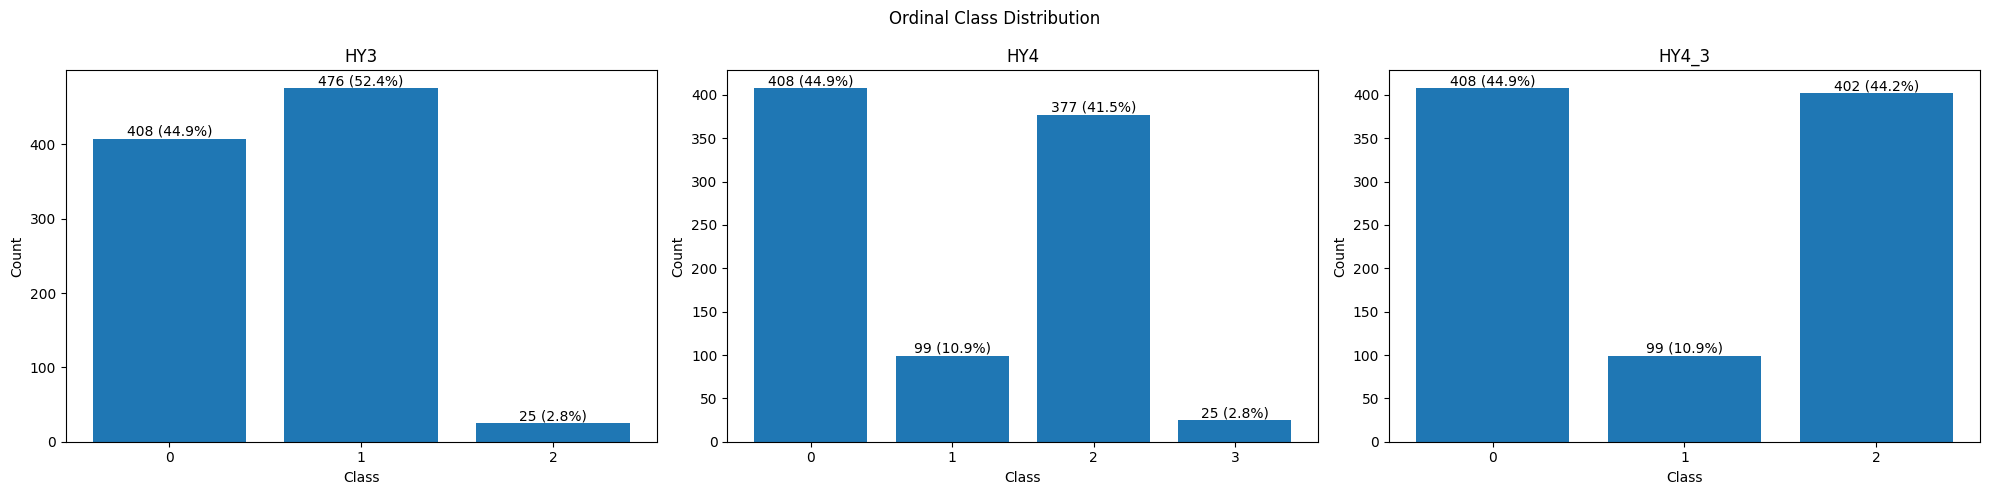

In [1]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[2]

import matplotlib.pyplot as plt


y_HY3 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv", index_col=0)
y_HY4 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY4.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv", index_col=0)
print("y_HY3 shape:", y_HY3.shape)
print("y_HY4 shape:", y_HY4.shape)
print("y_HY4_3 shape:", y_HY43.shape)

datasets = {
    "HY3": y_HY3,
    "HY4": y_HY4,
    'HY4_3': y_HY43
}

fig, axes = plt.subplots(1, 3, figsize=(20,5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# Files 

In [36]:
import os

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples= { 'X_STATS':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_STATS.csv', 
                    'X_V06_STATS': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+STATS.csv',
                      'X_V06_DELTA': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+Deltas.csv'}

y_multiples = { 'HY3': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv',
                'HY43': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv'
                }



targets = ["HY3", "HY43"]
domains = ["FULL_PPMI", "UPDRS"]
structures = ["X_STATS", "X_V06_STATS", "X_V06_DELTA"]
experiments = ["Default", "Feature_Selection", "Optimization"]

paths_output = {}

for t in targets:
    paths_output[t] = {}
    for d in domains:
        paths_output[t][d] = {}
        for s in structures:
            paths_output[t][d][s] = {}
            for e in experiments:
                path = os.path.join(project_root,'SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results', t, d, s, e)
                paths_output[t][d][s][e] = path

dominios_full = {
    'X_STATS': { 
        'motor': full_domain['SC_data'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['NM_data_STATS']
    },

    'X_V06_STATS': {
        'motor': full_domain['SC_data'] +full_domain['M_data_V06'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['SC_data'] + full_domain['NM_data_V06'] + full_domain['NM_data_STATS']
    },

    'X_V06_DELTA': {
        'motor': full_domain['SC_data'] + full_domain['M_data_V06'] + full_domain['M_data_DELTA'],
        'non_motor': full_domain['NM_data_V06'] + full_domain['NM_data_DELTA']
    }
}

dominios_updrs = {
    'X_STATS': {

        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_STATS': {
        
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_DELTA': {
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_delta'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_delta'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_delta']
    }
}




# Models Default

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectKBest, mutual_info_classif

classification_models = {

    "decision_tree": DecisionTreeClassifier(random_state=42),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "xgboost": XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ),


    "adaboost": AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,  
        random_state=42
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight="balanced"
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()
}

# Diccionario con MinMaxScaler
models_minmax = {
    "minmax_" + name: Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for name, model in classification_models.items()
}

# Diccionario con StandardScaler
models_standard = {
    "standard_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    for name, model in classification_models.items()
}


# Default Model Performance

## Pairwise models

### Performance Evaluation

In [41]:
import numpy as np
import pandas as pd

from itertools import combinations
from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
)


# =========================
# METRICS
# =========================
def _compute_metrics(y_true, y_pred, y_proba):
    metrics = {}

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, average="binary", zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, average="binary", zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, average="binary", zero_division=0)
    metrics["auc"] = roc_auc_score(y_true, y_proba)

    # ---- per-class metrics ----
    prec, rec, f1_vals, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    metrics["precision_class_0"] = prec[0]
    metrics["recall_class_0"] = rec[0]
    metrics["f1_class_0"] = f1_vals[0]
    metrics["support_class_0"] = supp[0]

    metrics["precision_class_1"] = prec[1]
    metrics["recall_class_1"] = rec[1]
    metrics["f1_class_1"] = f1_vals[1]
    metrics["support_class_1"] = supp[1]

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


# =========================
# BUILD FINAL ROW
# =========================
def _build_row(results, model_name, comparison, class_0_label, class_1_label):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "comparison": comparison,
        "class_0_label": class_0_label,
        "class_1_label": class_1_label,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


# =========================
# HELPERS
# =========================
def _get_positive_class_proba(model, X):
    proba = model.predict_proba(X)
    class_index = list(model.classes_).index(1)
    return proba[:, class_index]


# =========================
# MAIN FUNCTION
# =========================
def evaluate_models_pairwise_10x10_metrics(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    random_state=42,
):
    # ---- convert to numpy / dataframe compatible ----
    X_df = X.copy() if hasattr(X, "iloc") else pd.DataFrame(X)
    y_arr = y.values if hasattr(y, "values") else np.asarray(y)
    y_arr = y_arr.ravel()

    classes = np.sort(np.unique(y_arr))
    class_pairs = list(combinations(classes, 2))

    all_rows = []

    # =========================
    # LOOP MODELS
    # =========================
    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        # =========================
        # LOOP PAIRWISE TASKS
        # =========================
        for class_a, class_b in class_pairs:
            comparison_name = f"{class_a} vs {class_b}"
            print(f"  Evaluating comparison: {comparison_name}")

            mask = np.isin(y_arr, [class_a, class_b])
            X_pair = X_df.loc[mask].copy()
            y_pair = y_arr[mask]

            # class_a -> 0, class_b -> 1
            y_bin = np.where(y_pair == class_a, 0, 1)

            outer_cv = StratifiedShuffleSplit(
                n_splits=n_outer,
                test_size=test_size_outer,
                random_state=random_state
            )

            results = []

            # =========================
            # OUTER LOOP
            # =========================
            for outer_fold, (train_idx, test_idx) in enumerate(
                outer_cv.split(X_pair, y_bin),
                start=1
            ):
                X_train_outer = X_pair.iloc[train_idx]
                X_test_outer = X_pair.iloc[test_idx]
                y_train_outer = y_bin[train_idx]
                y_test_outer = y_bin[test_idx]

                
                inner_cv = StratifiedKFold(
                    n_splits=10,
                    shuffle=True,
                    random_state=random_state + outer_fold
                )

                inner_scores = []

                # =========================
                # INNER LOOP
                # =========================
                for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                    X_train_inner = X_train_outer.iloc[train_inner_idx]
                    y_train_inner = y_train_outer[train_inner_idx]
                    X_val_inner = X_train_outer.iloc[val_inner_idx]
                    y_val_inner = y_train_outer[val_inner_idx]

                    est = clone(model)
                    est.fit(X_train_inner, y_train_inner)

                    y_pred_val = est.predict(X_val_inner)
                    y_proba_val = _get_positive_class_proba(est, X_val_inner)

                    inner_scores.append(
                        _compute_metrics(
                            y_true=y_val_inner,
                            y_pred=y_pred_val,
                            y_proba=y_proba_val
                        )
                    )

                cv_mean_scores = _mean_metrics(inner_scores)

                # =========================
                # FINAL MODEL (OUTER TEST)
                # =========================
                final_model = clone(model)
                final_model.fit(X_train_outer, y_train_outer)

                y_pred_test = final_model.predict(X_test_outer)
                y_proba_test = _get_positive_class_proba(final_model, X_test_outer)

                test_scores = _compute_metrics(
                    y_true=y_test_outer,
                    y_pred=y_pred_test,
                    y_proba=y_proba_test
                )

                results.append({
                    "cv": cv_mean_scores,
                    "test": test_scores
                })

            # =========================
            # SAVE RESULT ROW
            # =========================
            all_rows.append(
                _build_row(
                    results=results,
                    model_name=model_name,
                    comparison=comparison_name,
                    class_0_label=class_a,
                    class_1_label=class_b,
                )
            )

    return pd.DataFrame(all_rows)

### Model Development

In [5]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_models_pairwise_10x10_metrics(model_dict=classification_models, X=X, y=y)
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_pairwise_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_pairwise_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_models_pairwise_10x10_metrics(model_dict=classification_models, X=X, y=y)
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_pairwise_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_pairwise_{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating model: decision_tree
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: random_forest
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: extra_trees
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: xgboost
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: adaboost
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: svm
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: logistic_regression
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evaluating comparison: 1 vs 2
Evaluating model: knn
  Evaluating comparison: 0 vs 1
  Evaluating comparison: 0 vs 2
  Evalua

## Single Model 
1. Model for: y > 0 
2. Model for: y > 1

### Performance Evaluation Function

In [6]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    mean_absolute_error,
    cohen_kappa_score,
    precision_recall_fscore_support,
)


# =========================
# METRICS
# =========================
def _compute_metrics(y_true, y_pred, y_proba=None):
    metrics = {}

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, average="binary", zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, average="binary", zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, average="binary", zero_division=0)
    metrics["mae"] = mean_absolute_error(y_true, y_pred)
    metrics["qwk"] = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    metrics["auc"] = roc_auc_score(y_true, y_proba[:, 1])

    # ---- per-class metrics ----
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    metrics["precision_class_0"] = prec[0]
    metrics["recall_class_0"] = rec[0]
    metrics["f1_class_0"] = f1[0]
    metrics["support_class_0"] = supp[0]

    metrics["precision_class_1"] = prec[1]
    metrics["recall_class_1"] = rec[1]
    metrics["f1_class_1"] = f1[1]
    metrics["support_class_1"] = supp[1]

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


# =========================
# BUILD FINAL ROW
# =========================
def _build_row(results, model_name, target_binary, class_0_label, class_1_label):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_binary": target_binary,
        "class_0_label": class_0_label,
        "class_1_label": class_1_label,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


# =========================
# MAIN FUNCTION
# =========================
def evaluate_model_10x10_metrics(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
):

    # ---- convert to numpy ----
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = y_arr.ravel()

    # ---- binary targets from multiclass ----
    binary_targets = [
        {
            "name": "y > 0",
            "y_bin": (y_arr > 0).astype(int),
            "class_0_label": "y == 0",
            "class_1_label": "y > 0",
        },
        {
            "name": "y > 1",
            "y_bin": (y_arr > 1).astype(int),
            "class_0_label": "y <= 1",
            "class_1_label": "y > 1",
        },
    ]

    all_rows = []

    # =========================
    # LOOP MODELS
    # =========================
    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        # =========================
        # LOOP BINARY TARGETS
        # =========================
        for target_info in binary_targets:
            print(f"  Evaluating target: {target_info['name']}")
            y_bin = target_info["y_bin"]

            outer_cv = StratifiedShuffleSplit(
                n_splits=n_outer,
                test_size=test_size_outer,
                random_state=random_state
            )

            results = []

            # =========================
            # OUTER LOOP
            # =========================
            for outer_fold, (train_idx, test_idx) in enumerate(
                outer_cv.split(X_arr, y_arr),  # stratify original
                start=1
            ):
                X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
                y_train_outer, y_test_outer = y_bin[train_idx], y_bin[test_idx]
                y_train_outer_multiclass = y_arr[train_idx]  # for inner stratification

                inner_cv = StratifiedShuffleSplit(
                    n_splits=n_inner,
                    test_size=test_size_inner,
                    random_state=random_state + outer_fold
                )

                inner_scores = []

                # =========================
                # INNER LOOP
                # =========================
                for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer_multiclass):

                    X_train_inner = X_train_outer[train_inner_idx]
                    y_train_inner = y_train_outer[train_inner_idx]
                    X_val_inner = X_train_outer[val_inner_idx]
                    y_val_inner = y_train_outer[val_inner_idx]

                    est = clone(model)
                    est.fit(X_train_inner, y_train_inner)

                    y_pred_val = est.predict(X_val_inner)

                    y_proba_val = (
                        est.predict_proba(X_val_inner)
                        if hasattr(est, "predict_proba")
                        else None
                    )

                    inner_scores.append(
                        _compute_metrics(
                            y_true=y_val_inner,
                            y_pred=y_pred_val,
                            y_proba=y_proba_val
                        )
                    )

                cv_mean_scores = _mean_metrics(inner_scores)

                # =========================
                # FINAL MODEL (OUTER TEST)
                # =========================
                final_model = clone(model)
                final_model.fit(X_train_outer, y_train_outer)

                y_pred_test = final_model.predict(X_test_outer)

                y_proba_test = (
                    final_model.predict_proba(X_test_outer)
                    if hasattr(final_model, "predict_proba")
                    else None
                )

                test_scores = _compute_metrics(
                    y_true=y_test_outer,
                    y_pred=y_pred_test,
                    y_proba=y_proba_test
                )

                results.append({
                    "cv": cv_mean_scores,
                    "test": test_scores
                })

            # =========================
            # SAVE RESULT ROW
            # =========================
            all_rows.append(
                _build_row(
                    results=results,
                    model_name=model_name,
                    target_binary=target_info["name"],
                    class_0_label=target_info["class_0_label"],
                    class_1_label=target_info["class_1_label"],
                )
            )

    return pd.DataFrame(all_rows)

### MODEL DEVELOPMENT

In [ ]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics(model_dict=classification_models, X=X, y=y)
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_ORDINAL_m1_m2_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_ORDINA_m1_m2_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics(model_dict=classification_models, X=X, y=y)
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_ORDINAL_m1_m2_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_ORDINA_m1_m2_{val}_{target}.csv')




Evaluating domain: X_STATS
Evaluating model: decision_tree
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: random_forest
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: extra_trees
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: xgboost
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: adaboost
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: svm
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: logistic_regression
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: knn
  Evaluating target: y > 0
  Evaluating target: y > 1
Evaluating model: gaussian_nb
  Evaluating target: y > 0
  Evaluating target: y > 1
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_ORDINAL_m1_m2_X_STATS_HY43.csv
Evaluating model: decision_tree
  Evaluating targ

# Ordinal Model Development

## Performance Evaluation Function


In [42]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    mean_absolute_error,
    cohen_kappa_score,
    precision_recall_fscore_support,
)


# =========================
# METRICS MULTICLASE
# =========================


def _compute_metrics(y_true, y_pred, y_proba=None, class_labels=None):
    metrics = {}

    if class_labels is None:
        class_labels = np.unique(np.concatenate([y_true, y_pred]))

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["mae"] = mean_absolute_error(y_true, y_pred)
    metrics["qwk"] = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    # ---- AUC multiclass ----
    if y_proba is not None:
        try:
            metrics["auc_ovr_macro"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["auc_ovr_weighted"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["auc_ovr_macro"] = np.nan
            metrics["auc_ovr_weighted"] = np.nan
    else:
        metrics["auc_ovr_macro"] = np.nan
        metrics["auc_ovr_weighted"] = np.nan

    # ---- per-class metrics ----
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    for i, cls in enumerate(class_labels):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # ---- directed confusion metrics for classes 0, 1, 2 ----
    for cls in [0, 1, 2]:
        mask_cls = (y_true == cls)
        wrong_cls = mask_cls & (y_pred != cls)

        if mask_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.mean(y_pred[mask_cls] == other_cls)
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.nan

        if wrong_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = np.mean(
                        y_pred[wrong_cls] == other_cls
                    )
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = 0.0

    return metrics

def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


# =========================
# HELPERS ORDINALES
# =========================
def _get_positive_proba(estimator, X):
    proba = estimator.predict_proba(X)
    return proba[:, 1]


def _enforce_ordinal_constraints(q1, q2):
    """
    Fuerza 1 >= q1 >= q2 >= 0
    """
    q1 = np.clip(q1, 0.0, 1.0)
    q2 = np.clip(q2, 0.0, 1.0)
    q2 = np.minimum(q2, q1)
    return q1, q2


def _cumulative_to_class_proba(q1, q2):
    """
    Convierte probabilidades acumulativas en probabilidades de clase:
      q1 = P(y >= 1)
      q2 = P(y >= 2)

      P(y=0) = 1 - q1
      P(y=1) = q1 - q2
      P(y=2) = q2
    """
    p0 = 1.0 - q1
    p1 = q1 - q2
    p2 = q2

    proba = np.column_stack([p0, p1, p2])

    # Seguridad numérica
    proba = np.clip(proba, 0.0, 1.0)
    row_sums = proba.sum(axis=1, keepdims=True)
    proba = proba / np.where(row_sums == 0, 1.0, row_sums)

    return proba


def _ordinal_proba_from_two_models(model_q1, model_q2, X):
    """
    q1 = P(y >= 1)
    q2 = P(y >= 2)

    Devuelve:
      - y_pred final
      - y_proba_clases: [P(y=0), P(y=1), P(y=2)]
      - df_probs: dataframe auxiliar
    """
    q1 = _get_positive_proba(model_q1, X)
    q2 = _get_positive_proba(model_q2, X)

    q1, q2 = _enforce_ordinal_constraints(q1, q2)
    y_proba_clases = _cumulative_to_class_proba(q1, q2)
    y_pred = np.argmax(y_proba_clases, axis=1)

    df_probs = pd.DataFrame({
        "q1_p_y_ge_1": q1,
        "q2_p_y_ge_2": q2,
        "P_class0": y_proba_clases[:, 0],
        "P_class1": y_proba_clases[:, 1],
        "P_class2": y_proba_clases[:, 2],
        "y_pred": y_pred,
    })

    return y_pred, y_proba_clases, df_probs


# =========================
# FIT CON SAMPLE_WEIGHT SI EXISTE
# =========================
def _fit_model(estimator, X, y, sample_weight=None):
    if sample_weight is not None:
        try:
            # Caso Pipeline
            if hasattr(estimator, "named_steps"):
                estimator.fit(X, y, model__sample_weight=sample_weight)
            else:
                estimator.fit(X, y, sample_weight=sample_weight)
            return estimator, True
        except TypeError:
            pass

    estimator.fit(X, y)
    return estimator, False


# =========================
# BUILD FINAL ROW
# =========================
def _build_row(results, model_name):
    metric_names = list(results[0]["cv"].keys())

    row = {"model": model_name}
    # True si en al menos un outer fold se usó sample_weight realmente
    row["used_sample_weight"] = any(r["used_sample_weight"] for r in results)
    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1) if len(cv_vals) > 1 else 0.0

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1) if len(test_vals) > 1 else 0.0

    

    return row


# =========================
# MAIN FUNCTION
# =========================
def evaluate_model_10x10_metrics_2models(
    model_dict: dict,
    X,
    y,
    sample_weights=None,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    return_fold_predictions=False,
):
    """
    Evalúa modelos ordinales de 3 clases (0,1,2) usando dos clasificadores binarios:
      q1 = P(y >= 1)
      q2 = P(y >= 2)

    Parámetros
    ----------
    model_dict : dict
        Diccionario {nombre_modelo: estimador_sklearn}
    X : array-like o DataFrame
    y : array-like o Series con valores {0,1,2}
    sample_weights : array-like, opcional
    n_outer : int
    n_inner : int
    test_size_outer : float
    test_size_inner : float
    random_state : int
    return_fold_predictions : bool
        Si True, devuelve también probabilidades/predicciones por fold.

    Retorna
    -------
    results_df : DataFrame
    fold_predictions_df : DataFrame opcional
    """

    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel()

    y_ge_1 = (y_arr >= 1).astype(int)   # q1
    y_ge_2 = (y_arr >= 2).astype(int)   # q2

    sample_weights_provided = sample_weights is not None

    if sample_weights is None:
        sample_weights = np.ones(len(y_arr), dtype=float)
    else:
        sample_weights = np.asarray(sample_weights, dtype=float).ravel()

    all_rows = []
    all_fold_predictions = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr), start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            y_train_outer_q1 = y_ge_1[train_idx]
            y_train_outer_q2 = y_ge_2[train_idx]

            w_train_outer = sample_weights[train_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for inner_fold, (train_inner_idx, val_inner_idx) in enumerate(
                inner_cv.split(X_train_outer, y_train_outer), start=1
            ):
                X_train_inner = X_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]

                y_train_inner_q1 = y_train_outer_q1[train_inner_idx]
                y_train_inner_q2 = y_train_outer_q2[train_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                w_train_inner = w_train_outer[train_inner_idx]

                # modelo para q1 = P(y >= 1)
                est_q1 = clone(model)
                est_q1, used_sw_q1_inner = _fit_model(
                    est_q1,
                    X_train_inner,
                    y_train_inner_q1,
                    sample_weight=w_train_inner if sample_weights_provided else None
                )

                # modelo para q2 = P(y >= 2)
                est_q2 = clone(model)
                est_q2, used_sw_q2_inner = _fit_model(
                    est_q2,
                    X_train_inner,
                    y_train_inner_q2,
                    sample_weight=w_train_inner if sample_weights_provided else None
                )

                # reconstrucción ordinal
                y_pred_val, y_proba_val, _ = _ordinal_proba_from_two_models(
                    est_q1, est_q2, X_val_inner
                )

                inner_scores.append(
                    _compute_metrics(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            # =========================
            # FINAL MODEL (OUTER TEST)
            # =========================
            final_q1 = clone(model)
            final_q2 = clone(model)

            final_q1, used_sw_q1_outer = _fit_model(
                final_q1,
                X_train_outer,
                y_train_outer_q1,
                sample_weight=w_train_outer if sample_weights_provided else None
            )

            final_q2, used_sw_q2_outer = _fit_model(
                final_q2,
                X_train_outer,
                y_train_outer_q2,
                sample_weight=w_train_outer if sample_weights_provided else None
            )

            used_sample_weight_outer = used_sw_q1_outer or used_sw_q2_outer

            y_pred_test, y_proba_test, df_probs_test = _ordinal_proba_from_two_models(
                final_q1, final_q2, X_test_outer
            )

            test_scores = _compute_metrics(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test
            )

            results.append({
                "cv": cv_mean_scores,
                "test": test_scores,
                "used_sample_weight": used_sample_weight_outer
            })

            if return_fold_predictions:
                df_fold = df_probs_test.copy()
                df_fold["model"] = model_name
                df_fold["outer_fold"] = outer_fold
                df_fold["y_true"] = y_test_outer
                df_fold["test_index"] = test_idx
                df_fold["used_sample_weight"] = used_sample_weight_outer
                all_fold_predictions.append(df_fold)

        all_rows.append(
            _build_row(
                results=results,
                model_name=model_name
            )
        )

    results_df = pd.DataFrame(all_rows)

    if return_fold_predictions:
        fold_predictions_df = pd.concat(all_fold_predictions, ignore_index=True)
        return results_df, fold_predictions_df

    return results_df

## MODEL DEVELOPMENT

In [9]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics_2models(model_dict=classification_models, 
                                                X=X, 
                                                y=y,
                                                sample_weights=y.iloc[:, 0].apply(lambda x: 2.0 if x > 0 else 1.0).to_list()) # ejemplo de sample_weight basado en clase
        
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_ORDINAL_2models{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_ORDINAL_2models{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics_2models(model_dict=classification_models, 
                                                X=X, 
                                                y=y,
                                                sample_weights=y.iloc[:, 0].apply(lambda x: 2.0 if x > 0 else 1.0).to_list()) # ejemplo de sample_weight basado en clase
        
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_ORDINAL_2models{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_ORDINAL_2models{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating model: extra_trees
Evaluating model: xgboost
Evaluating model: adaboost
Evaluating model: svm
Evaluating model: logistic_regression
Evaluating model: knn
Evaluating model: gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_ORDINAL_2modelsX_STATS_HY43.csv
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating model: extra_trees
Evaluating model: xgboost
Evaluating model: adaboost
Evaluating model: svm
Evaluating model: logistic_regression
Evaluating model: knn
Evaluating model: gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY3/UPDRS/X_STATS/Default/Default_ORDINAL_2modelsX_STATS_HY3.csv
Evaluating domain: X_V06_STATS
Evaluating model: decision_tree
Evaluating model: random_forest
Ev

In [43]:
# USING SCALERS

for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for scaler in ['MINMAX', 'STANDARD']:
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            else:
                model_dict_use = models_standard

            df=evaluate_model_10x10_metrics_2models(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y,
                                                sample_weights=y.iloc[:, 0].apply(lambda x: 2.0 if x > 0 else 1.0).to_list())
            
            print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_{scaler}_ORDINAL_2models{val}_{target}.csv')
            df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_{scaler}_ORDINAL_2models{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for scaler in ['MINMAX', 'STANDARD']:
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            else:
                model_dict_use = models_standard

            df=evaluate_model_10x10_metrics_2models(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y,
                                                sample_weights=y.iloc[:, 0].apply(lambda x: 2.0 if x > 0 else 1.0).to_list())
            
            print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_{scaler}_ORDINAL_2models{val}_{target}.csv')
            df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_{scaler}_ORDINAL_2models{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating model: minmax_decision_tree
Evaluating model: minmax_random_forest
Evaluating model: minmax_extra_trees
Evaluating model: minmax_xgboost
Evaluating model: minmax_adaboost
Evaluating model: minmax_svm
Evaluating model: minmax_logistic_regression
Evaluating model: minmax_knn
Evaluating model: minmax_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_MINMAX_ORDINAL_2modelsX_STATS_HY43.csv
Evaluating model: standard_decision_tree
Evaluating model: standard_random_forest
Evaluating model: standard_extra_trees
Evaluating model: standard_xgboost
Evaluating model: standard_adaboost
Evaluating model: standard_svm
Evaluating model: standard_logistic_regression
Evaluating model: standard_knn
Evaluating model: standard_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/

# Multiclass Model

## Performance Evaluation Function

In [44]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    mean_absolute_error,
    cohen_kappa_score,
    precision_recall_fscore_support,
)

def _compute_metrics_multiclass(
    y_true,
    y_pred,
    y_proba=None,
    class_labels=None,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    if class_labels is None:
        class_labels = np.unique(np.concatenate([y_true, y_pred]))

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["mae"] = mean_absolute_error(y_true, y_pred)
    metrics["qwk"] = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    # ---- misclassification disease cost ----

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1, 10],
            [1, 0, 1],
            [3, 1, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    # coste por observación: C[y_true_i, y_pred_i]
    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_disease_cost_mean"] = sample_costs.mean()
    metrics["misclassification_disease_cost_total"] = sample_costs.sum()
    metrics["misclassification_disease_score"] = -sample_costs.mean()

    # coste medio por clase real
    for cls in class_labels:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = np.nan

    # ---- AUC multiclass ----
    if y_proba is not None:
        try:
            metrics["auc_ovr_macro"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["auc_ovr_weighted"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["auc_ovr_macro"] = np.nan
            metrics["auc_ovr_weighted"] = np.nan
    else:
        metrics["auc_ovr_macro"] = np.nan
        metrics["auc_ovr_weighted"] = np.nan

    # ---- per-class metrics ----
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    for i, cls in enumerate(class_labels):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # ---- directed confusion metrics for classes 0, 1, 2 ----
    for cls in [0, 1, 2]:
        mask_cls = (y_true == cls)
        wrong_cls = mask_cls & (y_pred != cls)

        if mask_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.mean(y_pred[mask_cls] == other_cls)
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.nan

        if wrong_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = np.mean(
                        y_pred[wrong_cls] == other_cls
                    )
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


# =========================
# BUILD FINAL ROW
# =========================
def _build_row_multiclass(results, model_name, class_labels):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_type": "multiclass",
        "classes": list(class_labels),
        "n_classes": len(class_labels),
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


# =========================
# MAIN FUNCTION
# =========================
def evaluate_model_10x10_metrics_multiclass(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
):
    # ---- convert to numpy ----
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = y_arr.ravel()

    class_labels = np.unique(y_arr)

    all_rows = []

    # =========================
    # LOOP MODELS
    # =========================
    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        # =========================
        # OUTER LOOP
        # =========================
        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):

                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                y_pred_val = est.predict(X_val_inner)

                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                inner_scores.append(
                    _compute_metrics_multiclass(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val,
                        class_labels=class_labels
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            # =========================
            # FINAL MODEL (OUTER TEST)
            # =========================
            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_pred_test = final_model.predict(X_test_outer)

            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_multiclass(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                class_labels=class_labels
            )

            results.append({
                "cv": cv_mean_scores,
                "test": test_scores
            })

        # =========================
        # SAVE RESULT ROW
        # =========================
        all_rows.append(
            _build_row_multiclass(
                results=results,
                model_name=model_name,
                class_labels=class_labels,
            )
        )

    return pd.DataFrame(all_rows)

## Models Multiclass

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

classification_models_WB = {

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight = 'balanced'
    ),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
        # aquí NO va class_weight
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,  
        random_state=42,
        class_weight = 'balanced'
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight = 'balanced'
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()
}

In [51]:

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectKBest, mutual_info_classif


# Diccionario con MinMaxScaler
models_minmax = {
    "minmax_" + name: Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}

# Diccionario con StandardScaler
models_standard = {
    "standard_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}


models_minmax_RandomOversampling = {
    "minmax_" + name + "_RandomOversampling": Pipeline([
        ("scaler", MinMaxScaler()),
        ("sampler", RandomOverSampler(
            random_state=42,
            sampling_strategy={1: 100}
        )),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}

models_minmax_SMOTE = {
    "minmax_" + name + "_SMOTE": Pipeline([
        ("scaler", MinMaxScaler()),
        ("sampler", SMOTE(
            random_state=42,
            sampling_strategy={1: 100}
        )),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}


# solo modelos compatibles con RFECV
rfecv_compatible_models = {
    name: model
    for name, model in classification_models_WB.items()
    if name in [
        "decision_tree",
        "random_forest",
        "extra_trees",
        "xgboost",
        "logistic_regression"
    ]
}

models_minmax_RFECV = {
    f"minmax_{name}_RFECV": Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector1", SelectKBest(mutual_info_classif, k=100)),
        ("selector2", RFECV(
            estimator=clone(model),
            step=10,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring="f1_macro",
            n_jobs=-1
        )),
        ("model", clone(model))
    ])
    for name, model in rfecv_compatible_models.items()
}



## Model Development

In [17]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics_multiclass(model_dict=classification_models_WB, 
                                                X=X, 
                                                y=y,) 
        
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_MULTICLASS_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_MULTICLASS_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics_multiclass(model_dict=classification_models_WB, 
                                                X=X, 
                                                y=y)
        
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_MULTICLASS_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_MULTICLASS_{val}_{target}.csv')



Evaluating domain: X_STATS
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating model: extra_trees
Evaluating model: xgboost
Evaluating model: adaboost
Evaluating model: svm
Evaluating model: logistic_regression
Evaluating model: knn
Evaluating model: gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_MULTICLASS_X_STATS_HY43.csv
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating model: extra_trees
Evaluating model: xgboost
Evaluating model: adaboost
Evaluating model: svm
Evaluating model: logistic_regression
Evaluating model: knn
Evaluating model: gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY3/UPDRS/X_STATS/Default/Default_MULTICLASS_X_STATS_HY3.csv
Evaluating domain: X_V06_STATS
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating

In [46]:
# USING SCALERS

for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for scaler in ['MINMAX', 'STANDARD']:
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            else:
                model_dict_use = models_standard

            df=evaluate_model_10x10_metrics_multiclass(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y)
            
            print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_{scaler}_MULTICLASS_{val}_{target}.csv')
            df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_{scaler}_MULTICLASS_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for scaler in ['MINMAX', 'STANDARD']:
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            else:
                model_dict_use = models_standard

            df=evaluate_model_10x10_metrics_multiclass(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y)
            
            print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_{scaler}_MULTICLASS_{val}_{target}.csv')
            df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_{scaler}_MULTICLASS_{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating model: minmax_decision_tree
Evaluating model: minmax_random_forest
Evaluating model: minmax_extra_trees
Evaluating model: minmax_xgboost
Evaluating model: minmax_adaboost
Evaluating model: minmax_svm
Evaluating model: minmax_logistic_regression
Evaluating model: minmax_knn
Evaluating model: minmax_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_MINMAX_MULTICLASS_X_STATS_HY43.csv
Evaluating model: standard_decision_tree
Evaluating model: standard_random_forest
Evaluating model: standard_extra_trees
Evaluating model: standard_xgboost
Evaluating model: standard_adaboost
Evaluating model: standard_svm
Evaluating model: standard_logistic_regression
Evaluating model: standard_knn
Evaluating model: standard_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_ST

In [ ]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)  
        list_dfs = []

        for domain in dominios_updrs[val]:
            print(f"Evaluating subdomain: {domain}")
            df=evaluate_model_10x10_metrics_multiclass(model_dict=models_minmax, 
                                                    X=X[dominios_updrs[val][domain]], 
                                                    y=y)
            df["Subdomain"] = domain
            list_dfs.append(df)
        
        df_final=pd.concat(list_dfs, ignore_index=True)
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Feature_Selection"]}/Default_MULTICLASS_BY_DOMAIN_{val}_{target}.csv')
        df_final.to_csv(f'{paths_output[target]["UPDRS"][val]["Feature_Selection"]}/Default_MULTICLASS_BY_DOMAIN_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        list_dfs = []

        for domain in dominios_full[val]:
            print(f"Evaluating subdomain: {domain}")    
            df=evaluate_model_10x10_metrics_multiclass(model_dict=models_minmax, 
                                                    X=X, 
                                                    y=y)
            df["Subdomain"] = domain
            list_dfs.append(df)
        
        df_final=pd.concat(list_dfs, ignore_index=True)
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Feature_Selection"]}/Default_MULTICLASS_BY_DOMAIN_{val}_{target}.csv')
        df_final.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Feature_Selection"]}/Default_MULTICLASS_BY_DOMAIN_{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating subdomain: examen_motor
Evaluating model: minmax_decision_tree
Evaluating model: minmax_random_forest
Evaluating model: minmax_extra_trees
Evaluating model: minmax_xgboost
Evaluating model: minmax_adaboost
Evaluating model: minmax_svm
Evaluating model: minmax_logistic_regression
Evaluating model: minmax_knn
Evaluating model: minmax_gaussian_nb
Evaluating subdomain: impacto_motor
Evaluating model: minmax_decision_tree
Evaluating model: minmax_random_forest
Evaluating model: minmax_extra_trees
Evaluating model: minmax_xgboost
Evaluating model: minmax_adaboost
Evaluating model: minmax_svm
Evaluating model: minmax_logistic_regression
Evaluating model: minmax_knn
Evaluating model: minmax_gaussian_nb
Evaluating subdomain: non_motor
Evaluating model: minmax_decision_tree
Evaluating model: minmax_random_forest
Evaluating model: minmax_extra_trees
Evaluating model: minmax_xgboost
Evaluating model: minmax_adaboost
Evaluating model: minmax_svm
Evaluating mode

# STACKING MODELS Weights Correction
El objetivo del *stacking* es mejorar el rendimiento combinando modelos, donde el segundo modelo aprende a partir de las salidas del primero.

In [ ]:
from sklearn.ensemble import StackingClassifier

classification_models_stacking = {

    "STACKING_decision_tree": StackingClassifier(
        estimators=[("decision_tree", DecisionTreeClassifier(random_state=42))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),

    "STACKING_random_forest": StackingClassifier(
        estimators=[("random_forest", RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),

    "STACKING_extra_trees": StackingClassifier(
        estimators=[("extra_trees", ExtraTreesClassifier(
            random_state=42,
            n_jobs=-1
        ))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),

    "STACKING_xgboost": StackingClassifier(
        estimators=[("xgboost", XGBClassifier(
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        ))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),

    "STACKING_adaboost": StackingClassifier(
        estimators=[("adaboost", AdaBoostClassifier(
            algorithm="SAMME",
            random_state=42
        ))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),

    "STACKING_svm": StackingClassifier(
        estimators=[("svm", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),


    "STACKING_knn": StackingClassifier(
        estimators=[("knn", KNeighborsClassifier(
            n_jobs=-1
        ))],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    ),

    "STACKING_gaussian_nb": StackingClassifier(
        estimators=[("gaussian_nb", GaussianNB())],
        final_estimator=LogisticRegression(
            penalty="l2",
            C=0.3,
            solver="lbfgs",
            max_iter=10000,
            class_weight="balanced",
            random_state=42
        ),
        stack_method="predict_proba",
        cv=5,
        n_jobs=-1
    )
}

# Diccionario con MinMaxScaler
models_minmax = {
    "minmax_" + name: Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for name, model in classification_models_stacking.items()
}

# Diccionario con StandardScaler
models_standard = {
    "standard_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    for name, model in classification_models_stacking.items()
}


## Model Development

In [ ]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics_multiclass(model_dict=classification_models_stacking, 
                                                X=X, 
                                                y=y,) 
        
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_MULTICLASS_STACKING_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_MULTICLASS_STACKING_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)    
        df=evaluate_model_10x10_metrics_multiclass(model_dict=classification_models_stacking, 
                                                X=X, 
                                                y=y)
        
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_MULTICLASS_STACKING_{val}_{target}.csv')
        df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_MULTICLASS_STACKING_{val}_{target}.csv')



Evaluating domain: X_STATS
Evaluating model: STACKING_decision_tree
Evaluating model: STACKING_random_forest
Evaluating model: STACKING_extra_trees
Evaluating model: STACKING_xgboost
Evaluating model: STACKING_adaboost
Evaluating model: STACKING_svm
Evaluating model: STACKING_knn
Evaluating model: STACKING_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_MULTICLASS_STACKING_X_STATS_HY43.csv
Evaluating model: STACKING_decision_tree
Evaluating model: STACKING_random_forest
Evaluating model: STACKING_extra_trees
Evaluating model: STACKING_xgboost
Evaluating model: STACKING_adaboost
Evaluating model: STACKING_svm
Evaluating model: STACKING_knn
Evaluating model: STACKING_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY3/UPDRS/X_STATS/Default/Default_MULTICLASS_STACKING_X_STATS_HY3.csv
Evaluating domain: 

In [48]:
# USING SCALERS

for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for scaler in ['MINMAX', 'STANDARD']:
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            else:
                model_dict_use = models_standard

            df=evaluate_model_10x10_metrics_multiclass(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y)
            
            print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Default"]}/Default_{scaler}_MULTICLASS_STACKING_{val}_{target}.csv')
            df.to_csv(f'{paths_output[target]["UPDRS"][val]["Default"]}/Default_{scaler}_MULTICLASS_STACKING_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for scaler in ['MINMAX', 'STANDARD']:
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            else:
                model_dict_use = models_standard

            df=evaluate_model_10x10_metrics_multiclass(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y)
            
            print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_{scaler}_MULTICLASS_STACKING_{val}_{target}.csv')
            df.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Default"]}/Default_{scaler}_MULTICLASS_STACKING_{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating model: minmax_STACKING_decision_tree
Evaluating model: minmax_STACKING_random_forest
Evaluating model: minmax_STACKING_extra_trees
Evaluating model: minmax_STACKING_xgboost
Evaluating model: minmax_STACKING_adaboost
Evaluating model: minmax_STACKING_svm
Evaluating model: minmax_STACKING_knn
Evaluating model: minmax_STACKING_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY43/UPDRS/X_STATS/Default/Default_MINMAX_MULTICLASS_STACKING_X_STATS_HY43.csv
Evaluating model: standard_STACKING_decision_tree
Evaluating model: standard_STACKING_random_forest
Evaluating model: standard_STACKING_extra_trees
Evaluating model: standard_STACKING_xgboost
Evaluating model: standard_STACKING_adaboost
Evaluating model: standard_STACKING_svm
Evaluating model: standard_STACKING_knn
Evaluating model: standard_STACKING_gaussian_nb
        Results saved to /home/fsc/Desktop/PD_progression_ppmi/SCRI

# STACKING MULTIDOMAIN
Cada uno de estos dominios presenta diferente capacidad predictiva (medida, por ejemplo, mediante AUC), lo que sugiere que no todos aportan la misma cantidad de información al problema de clasificación.

## EARLY SELECTION

### Model Development

In [ ]:
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)  
        list_dfs = []

        for domain in dominios_updrs[val]:
            print(f"Evaluating subdomain: {domain}")
            df=evaluate_model_10x10_metrics_multiclass(model_dict=models_minmax, 
                                                    X=X[dominios_updrs[val][domain]], 
                                                    y=y)
            df["Subdomain"] = domain
            list_dfs.append(df)
        
        df_final=pd.concat(list_dfs, ignore_index=True)
        print(f'        Results saved to {paths_output[target]["UPDRS"][val]["Feature_Selection"]}/Default_MULTICLASS_STACKING_BY_DOMAIN_{val}_{target}.csv')
        df_final.to_csv(f'{paths_output[target]["UPDRS"][val]["Feature_Selection"]}/Default_MULTICLASS_STACKING_BY_DOMAIN_{val}_{target}.csv')


for val in dominios_full:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    for target in ['HY43', 'HY3']:
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        list_dfs = []

        for domain in dominios_full[val]:
            print(f"Evaluating subdomain: {domain}")    
            df=evaluate_model_10x10_metrics_multiclass(model_dict=models_minmax, 
                                                    X=X, 
                                                    y=y)
            df["Subdomain"] = domain
            list_dfs.append(df)
        
        df_final=pd.concat(list_dfs, ignore_index=True)
        print(f'        Results saved to {paths_output[target]["FULL_PPMI"][val]["Feature_Selection"]}/Default_MULTICLASS_STACKING_BY_DOMAIN_{val}_{target}.csv')
        df_final.to_csv(f'{paths_output[target]["FULL_PPMI"][val]["Feature_Selection"]}/Default_MULTICLASS_STACKING_BY_DOMAIN_{val}_{target}.csv')

Evaluating domain: X_STATS
Evaluating subdomain: examen_motor
Evaluating model: minmax_STACKING_decision_tree
Evaluating model: minmax_STACKING_random_forest
Evaluating model: minmax_STACKING_extra_trees
Evaluating model: minmax_STACKING_xgboost
Evaluating model: minmax_STACKING_adaboost
Evaluating model: minmax_STACKING_svm
Evaluating model: minmax_STACKING_knn
Evaluating model: minmax_STACKING_gaussian_nb
Evaluating subdomain: impacto_motor
Evaluating model: minmax_STACKING_decision_tree
Evaluating model: minmax_STACKING_random_forest
Evaluating model: minmax_STACKING_extra_trees
Evaluating model: minmax_STACKING_xgboost
Evaluating model: minmax_STACKING_adaboost
Evaluating model: minmax_STACKING_svm
Evaluating model: minmax_STACKING_knn
Evaluating model: minmax_STACKING_gaussian_nb
Evaluating subdomain: non_motor
Evaluating model: minmax_STACKING_decision_tree
Evaluating model: minmax_STACKING_random_forest
Evaluating model: minmax_STACKING_extra_trees
Evaluating model: minmax_STACK

KeyboardInterrupt: 

## Possible funcion de desarrollo de modelos stacked por dominio